## Load data

In [24]:
from pandas import DataFrame
import sys
sys.path.append('/Users/davebrunner/Documents/repositories/SelfClean/')
from selfclean.core.src.pkg.helper import get_embedding, EmbeddingPoolingType
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from torch import Tensor

random_state = 42

# Load data
hs_train = pd.read_json("../../experiment/datasets/goldenswag/golden_swag_train.json")

# Extract off-topic IDs
# off_topic_ids = set(log["id"] for log in hs_train_logs.to_dict("records"))

# Prepare data
data = {}
for id, entry in hs_train.iterrows():
    context = entry["ctx"]
    correct_ending = entry["endings"][entry["label"]]
    wrong_endings = [entry["endings"][i] for i in [0, 1, 2, 3] if i != entry["label"]]
    task_id = str(entry["ind"])
    is_offtopic = None

    data_point = {
        "text": context + " " + correct_ending,
        "correct": 1,
        "category": entry["activity_label"],
        "task_id": id,
        "off_topic": is_offtopic
    }
    data[len(data)] = data_point
    for wrong in wrong_endings:
        data_point = {
            "text": context + " " + wrong,
            "correct": 0,
            "category": entry["activity_label"],
            "task_id": id,
            "off_topic": is_offtopic
        }
        data[len(data)] = data_point

df = pd.DataFrame.from_dict(data, orient="index")


def filter_df(df: DataFrame, top_n_categories: int, n_samples: int) -> DataFrame:
    # Get top N categories
    top_n_categories = df['category'].value_counts().head(top_n_categories).index.tolist()
    filtered_df = df[df["category"].isin(top_n_categories)]

    # Group by task_id and sample groups rather than individual rows
    grouped = filtered_df.groupby('task_id')

    # Get list of all task_ids
    task_ids = list(grouped.groups.keys())

    # Sample task_ids (not individual rows)
    sampled_task_ids = pd.Series(task_ids).sample(n=min(round(n_samples / 4), len(task_ids)), random_state=random_state)

    # Get all rows for the sampled task_ids
    sampled_df = filtered_df[filtered_df['task_id'].isin(sampled_task_ids)]

    print(f"Number of samples={len(sampled_df)}, got {len(sampled_task_ids)} task groups")
    return sampled_df.reset_index(drop=True)

# Example: Filter for 'sports' category and 100 samples

# Load model and tokenizer
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = AutoModel.from_pretrained('../models/Electra_golden_swag_train/epoch35').to(device)
tokenizer = AutoTokenizer.from_pretrained('google/electra-base-discriminator')
model.train(False)

# Generate embeddings for all pooling types
def get_embeddings(df: pd.DataFrame) -> dict[EmbeddingPoolingType, Tensor]:
    inputs = tokenizer(df["text"].tolist(), padding=True, truncation=True, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    embeddings = {}
    with torch.no_grad():
        emb = model(**inputs, return_dict=True, output_hidden_states=True)
        for pooling_type in EmbeddingPoolingType:
            embeddings[pooling_type] = get_embedding(emb, inputs, pooling_type)

    return embeddings


Some weights of the model checkpoint at ../models/Electra_golden_swag_train/epoch35 were not used when initializing ElectraModel: ['discriminator_predictions.dense.bias', 'discriminator_predictions.dense.weight', 'discriminator_predictions.dense_prediction.weight', 'discriminator_predictions.dense_prediction.bias']
- This IS expected if you are initializing ElectraModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ElectraModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


# 300 samples with four different embedding poolings approaches 3D PCA

In [25]:
filtered_df = filter_df(df, 150, n_samples=300)
embeddings = get_embeddings(filtered_df)
embeddings = {k: v.cpu() for k, v in embeddings.items()}

Number of samples=300, got 75 task groups


In [26]:
from examples.text_embedding_visualization.plot_pca import plot_pca_3d_combined

plot_pca_3d_combined(
    embeddings_cls=embeddings[EmbeddingPoolingType.CLS],
    embeddings_mean=embeddings[EmbeddingPoolingType.MEAN],
    embeddings_first_last=embeddings[EmbeddingPoolingType.FIRST_LAST_AVERAGE],
    embeddings_max=embeddings[EmbeddingPoolingType.MAX],
    df=filtered_df,
    color_label="Embedding Pooling Type",
    model_name="DeBERTaV3"
)

/Users/davebrunner/Documents/repositories/SelfClean/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



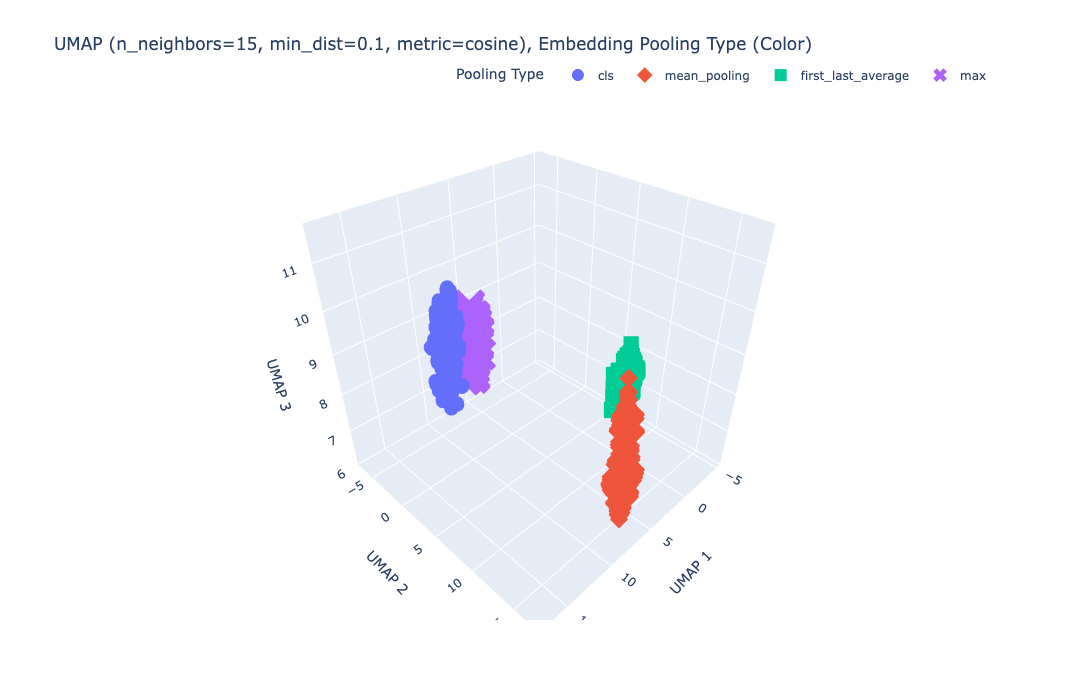

tensor([[15.9750,  7.3092, 10.6280],
        [16.0200,  7.3446, 10.5881],
        [16.0393,  7.4128, 10.4994],
        ...,
        [ 6.3176, -5.9976,  7.4201],
        [ 6.3595, -5.8917,  7.5048],
        [ 6.2760, -5.9567,  7.5135]])

In [36]:
from examples.text_embedding_visualization.plot_umap import plot_umap_2d_combined, plot_umap_3d_combined

plot_umap_3d_combined(
    embeddings_cls=embeddings[EmbeddingPoolingType.CLS],
    embeddings_mean=embeddings[EmbeddingPoolingType.MEAN],
    embeddings_first_last=embeddings[EmbeddingPoolingType.FIRST_LAST_AVERAGE],
    embeddings_max=embeddings[EmbeddingPoolingType.MAX],
    df=filtered_df,
    color_label="Embedding Pooling Type",
    model_name="DeBERTaV3",
    n_neighbors=15,
    min_dist=0.1
)